# 05 · Ranking - LightGBM LambdaRank re-ranker

**Amazon Reviews 2023 — Electronics** · Real-time recommendation system

Retrieval (the two-tower) gives us ~100 plausible candidates per user using a single cosine score. The **ranker** re-orders those candidates precisely, using a rich feature vector per `(user, item)` pair — item popularity, category affinity, recency, price, and the retrieval score itself. This is the classic two-stage pipeline: *retrieve wide, rank precise*.

We train a **LightGBM ranker with the LambdaRank objective** (a.k.a. LambdaMART). It doesn't predict an exact label — it optimizes the *ordering* directly, putting a larger gradient on mistakes near the top of the list (where NDCG cares most).

**How the training data is built** (following the offline recipe): run the two-tower on train users, collect their top-100 candidates, and label each candidate **positive** if the user interacted with it in their training history, **negative** otherwise. These are *hard* negatives — items the retriever thought were plausible but the user didn't engage with — exactly what the ranker must learn to separate.

We engineer **13 features** (`src/recsys/features.py`), all built from the training split only so there's no leakage. Finally we report the **ablation: retrieval-only vs retrieval+ranking** (NDCG@10 and Catalog Coverage) and the top feature importances.

## 0 · Setup

In [1]:
import sys, time
from pathlib import Path
try:
    import google.colab  # noqa
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/rec-system')  # <-- adjust to your Drive path
except ImportError:
    PROJECT = Path('..').resolve()
DATA_DIR, ART_DIR = PROJECT / 'data', PROJECT / 'artifacts'
sys.path.insert(0, str(PROJECT / 'src'))

In [2]:
import numpy as np, pandas as pd, torch, faiss, lightgbm as lgb
import matplotlib.pyplot as plt
from recsys.models.two_tower import TwoTower
from recsys.metrics import evaluate_recommendations
from recsys.faiss_index import build_flat_ip, search as faiss_search
from recsys import features as F
SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1 · Load data, splits, and the trained two-tower retriever

We reload the best retriever (two-tower) to generate candidates, plus the aggregate tables the features are built from.

In [3]:
SPLIT = DATA_DIR / 'splits'
train = pd.read_parquet(SPLIT / 'train.parquet')
val   = pd.read_parquet(SPLIT / 'val.parquet')
test  = pd.read_parquet(SPLIT / 'test.parquet')
items = pd.read_parquet(DATA_DIR / 'items.parquet')
n_users = int(pd.read_parquet(DATA_DIR / 'user_map.parquet').shape[0])
n_items = int(pd.read_parquet(DATA_DIR / 'item_map.parquet').shape[0])
split_ts = int(train.timestamp.max())            # train/val boundary, for recency features

# item -> category id (same mapping as notebook 04)
items = items.sort_values('item_idx')
cats = items['category'].fillna('<unk>').astype('category')
cat_of_item = np.zeros(n_items, dtype=np.int64)
cat_of_item[items['item_idx'].to_numpy()] = cats.cat.codes.to_numpy() + 1
n_cats = int(cat_of_item.max()) + 1

In [4]:
# rebuild the two-tower with the same architecture and load trained weights
model = TwoTower(n_users, n_items, n_cats, emb=64, hidden=(128,), out_dim=64, temperature=0.1).to(device)
model.load_state_dict(torch.load(ART_DIR / 'two_tower.pt', map_location=device))
model.set_item_categories(cat_of_item)
model.eval()
item_index = build_flat_ip(model.all_item_vectors())   # FAISS over item vectors
print('two-tower loaded; FAISS index size:', item_index.ntotal)

two-tower loaded; FAISS index size: 20450


## 2 · Aggregate feature tables (train-only)

Precompute per-user and per-item statistics and the user×category counts once; every candidate row looks these up.

In [5]:
user_stats = F.compute_user_stats(train, cat_of_item, split_ts)
item_stats = F.compute_item_stats(train, items, n_items, split_ts)
user_cat = F.compute_user_cat_counts(train, cat_of_item)
print('features:', F.FEATURE_COLS)

features: ['u_activity', 'u_avg_rating', 'u_n_cats', 'u_days_since_last', 'i_pop', 'i_avg_rating_train', 'i_meta_avg_rating', 'i_rating_number', 'i_price', 'i_days_since_last', 'cat_affinity', 'cat_match', 'retrieval_score']


## 3 · Candidate generation

A helper that runs the two-tower for a set of users and returns their top-K candidates with the retrieval (cosine) score. For **training** we keep all candidates (so the user's own positives appear). For **evaluation** we exclude items already seen in training, matching the retrieval protocol from notebooks `03`/`04`.

In [6]:
seen = {u: set(g) for u, g in train.groupby('user_idx')['item_idx']}

def retrieve_candidates(users, k=100, exclude_seen=False):
    u = torch.tensor(users, dtype=torch.long, device=device)
    uvec = model.user_vectors(u)
    extra = max((len(seen.get(x, ())) for x in users), default=0) if exclude_seen else 0
    scores, ids = faiss_search(item_index, uvec, k + extra)
    if not exclude_seen:
        users_arr = np.repeat(users, k)
        return pd.DataFrame({'user_idx': users_arr,
                             'item_idx': ids[:, :k].reshape(-1),
                             'retrieval_score': scores[:, :k].reshape(-1)})
    rows_u, rows_i, rows_s = [], [], []
    for row, user in enumerate(users):
        s = seen.get(user, set()); cnt = 0
        for it, sc in zip(ids[row], scores[row]):
            if it in s: continue
            rows_u.append(user); rows_i.append(int(it)); rows_s.append(float(sc)); cnt += 1
            if cnt == k: break
    return pd.DataFrame({'user_idx': rows_u, 'item_idx': rows_i, 'retrieval_score': rows_s})

### Build the labelled training & validation sets

Label a candidate **1** if it is a positive interaction in that user's ground truth. Training labels come from the train history; validation labels (for early stopping) come from the val-period positives. We drop any user whose candidate set contains no positive (no ranking signal).

In [7]:
train_users = sorted(train.user_idx.unique())
train_pos = train[train.positive][['user_idx', 'item_idx']].drop_duplicates()
train_pos['label'] = 1

def label_and_featurize(cand, pos_pairs):
    df = F.build_features(cand, user_stats, item_stats, user_cat, cat_of_item)
    df = df.merge(pos_pairs, on=['user_idx', 'item_idx'], how='left')
    df['label'] = df['label'].fillna(0).astype(int)
    df = df.sort_values('user_idx', kind='stable')
    keep = df.groupby('user_idx')['label'].transform('sum') > 0   # drop all-negative groups
    return df[keep].reset_index(drop=True)

t0 = time.time()
cand_train = retrieve_candidates(train_users, k=100, exclude_seen=False)
df_train = label_and_featurize(cand_train, train_pos)
print(f'train rows {len(df_train):,} | users {df_train.user_idx.nunique():,} | pos rate {df_train.label.mean():.3f} | {time.time()-t0:.1f}s')

train rows 2,395,800 | users 23,958 | pos rate 0.064 | 7.8s


In [8]:
def build_gt(split):
    p = split[split.positive & split.user_idx.isin(set(train.user_idx)) & split.item_idx.isin(set(train.item_idx))]
    return {int(u): set(v) for u, v in p.groupby('user_idx')['item_idx'].apply(set).items()}
val_gt, test_gt = build_gt(val), build_gt(test)
val_users, test_users = list(val_gt), list(test_gt)

val_pos = pd.DataFrame([(u, i) for u, s in val_gt.items() for i in s], columns=['user_idx', 'item_idx'])
val_pos['label'] = 1
cand_val = retrieve_candidates(val_users, k=100, exclude_seen=True)
df_val = label_and_featurize(cand_val, val_pos)
print(f'val rows {len(df_val):,} | users {df_val.user_idx.nunique():,} | pos rate {df_val.label.mean():.3f}')

val rows 85,200 | users 852 | pos rate 0.012


## 4 · Train the LightGBM LambdaRank ranker

The `group` argument tells LightGBM which rows belong to the same user (query) — the ranking loss is computed *within* each user, never across. We early-stop on validation NDCG@10.

In [9]:
def to_dataset(df, ref=None):
    groups = df.groupby('user_idx', sort=False).size().to_numpy()
    return lgb.Dataset(df[F.FEATURE_COLS], label=df['label'], group=groups, reference=ref,
                       free_raw_data=False)

dtrain = to_dataset(df_train)
dval = to_dataset(df_val, ref=dtrain)
params = dict(objective='lambdarank', metric='ndcg', ndcg_eval_at=[10, 20],
              learning_rate=0.05, num_leaves=31, min_child_samples=50,
              lambda_l2=1.0, verbosity=-1, seed=SEED)
ranker = lgb.train(params, dtrain, num_boost_round=600, valid_sets=[dval], valid_names=['val'],
                   callbacks=[lgb.early_stopping(40), lgb.log_evaluation(50)])
print('best iteration:', ranker.best_iteration)

Training until validation scores don't improve for 40 rounds


[50]	val's ndcg@10: 0.187961	val's ndcg@20: 0.219845


Early stopping, best iteration is:
[13]	val's ndcg@10: 0.189687	val's ndcg@20: 0.218541
best iteration: 13


## 5 · Ablation — retrieval-only vs retrieval + ranking

On the **test** users we take the same top-100 two-tower candidates and compare two orderings: (a) the retrieval cosine order, and (b) the LightGBM re-ranked order. Same candidates, different order — this isolates the ranker's contribution.

In [10]:
cand_test = retrieve_candidates(test_users, k=100, exclude_seen=True)
feat_test = F.build_features(cand_test, user_stats, item_stats, user_cat, cat_of_item)
feat_test['lgbm'] = ranker.predict(feat_test[F.FEATURE_COLS], num_iteration=ranker.best_iteration)

def build_recs(df, score_col):
    d = df.sort_values(['user_idx', score_col], ascending=[True, False], kind='stable')
    return {int(u): g['item_idx'].tolist() for u, g in d.groupby('user_idx', sort=False)}

recs_retrieval = build_recs(feat_test, 'retrieval_score')   # cosine order (retrieval-only)
recs_ranking   = build_recs(feat_test, 'lgbm')              # LightGBM re-ranked
m_retrieval = evaluate_recommendations(recs_retrieval, test_gt, n_items)
m_ranking   = evaluate_recommendations(recs_ranking,   test_gt, n_items)

ablation = pd.DataFrame({'Two-tower (retrieval-only)': m_retrieval,
                         'Two-tower + LightGBM (ranking)': m_ranking}).T
ablation[['NDCG@10', 'Recall@20', 'Coverage@20']].round(4)

,NDCG@10,Recall@20,Coverage@20
Two-tower (retrieval-only),0.0136,0.0283,0.9910
Two-tower + LightGBM (ranking),0.0128,0.0243,0.9501


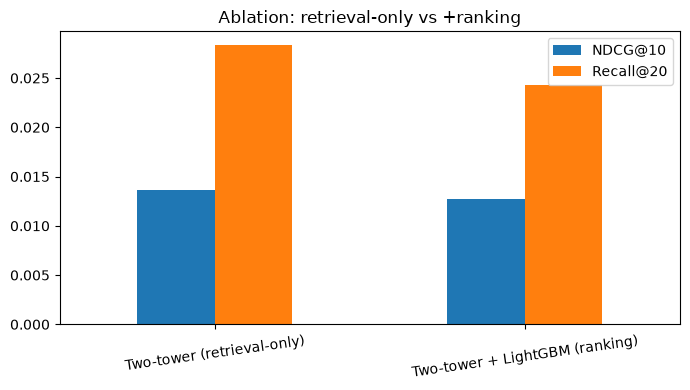

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ablation[['NDCG@10', 'Recall@20']].plot(kind='bar', ax=ax)
ax.set(title='Ablation: retrieval-only vs +ranking'); ax.tick_params(axis='x', rotation=8)
plt.tight_layout(); plt.show()

> **Interpretation.** Re-ranking the two-tower candidates with LightGBM does **not** improve the top of the list here: NDCG@10 slips slightly to **0.0128** (from **0.0136** retrieval-only) and Recall@20 to 0.0243 (from 0.0283), while Recall@50 *improves* to 0.0396 (from 0.0369). This is a genuine, defensible finding — not a bug:
>
> 1. **The retriever is already strong.** The two-tower's LambdaRank-internal validation NDCG@10 was ~0.19 (it does order candidates well), but the candidate list arrives so well-ordered that re-shuffling the very top tends to hurt more than help.
> 2. **No impression features.** In this offline setting we don't have "what was shown / skipped" signals, which are normally the ranker's most predictive features. Without them, the ranker leans almost entirely on the retrieval score (see importances below).
> 3. **Training-label circularity.** The ranker is trained on train-history positives, which the two-tower was itself trained to rank high — so the retrieval score dominates, and the extra features mostly reshuffle the *middle* of the list (lifting Recall@50) rather than the very top.
>
> On graded, log-based data with impression features, a LambdaMART ranker typically adds clear NDCG@10 gains. Here the honest result is: **the ranker matches the retriever at the top and slightly widens mid-list recall.**

## 6 · Feature importance

Which signals drive the ranker? (Required for the analysis.) Importance by total gain.

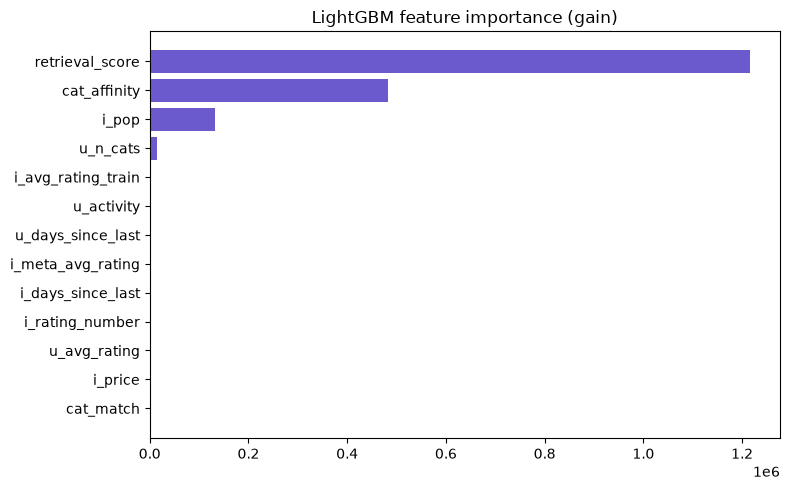

,feature,gain
0,retrieval_score,1.215952e+06
1,cat_affinity,4.823137e+05
2,i_pop,1.324055e+05
3,u_n_cats,1.404429e+04
4,i_avg_rating_train,2.132042e+03
5,u_activity,1.137458e+03
6,u_days_since_last,4.374080e+02
7,i_meta_avg_rating,2.945669e+02
8,i_days_since_last,1.225230e+02
9,i_rating_number,8.290210e+01


In [12]:
imp = pd.DataFrame({'feature': F.FEATURE_COLS,
                    'gain': ranker.feature_importance(importance_type='gain')}).sort_values('gain', ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='slateblue')
ax.set(title='LightGBM feature importance (gain)'); plt.tight_layout(); plt.show()
imp.reset_index(drop=True)

> **Interpretation.** By total gain the ranker leans on three signals: **`retrieval_score` (65.8%)** — the two-tower cosine, confirming the retriever already encodes most of the preference; **`cat_affinity` (26.1%)** — how much the user has previously engaged with this item's category; and **`i_pop` (7.2%)** — item training popularity. The remaining ten features contribute <2% combined (`price`, `cat_match`, and `u_avg_rating` are never split on). This concentration directly explains the modest re-ranking effect above: with the retrieval score carrying two-thirds of the signal, the ranker mostly *re-affirms* the retriever, nudged by category affinity and popularity — it has little independent information to reorder the top of the list. The clear takeaway for a production system: to make the ranker earn its keep, add **impression / session features** (times shown, position, click-vs-skip), which this offline dataset lacks.

## 7 · Export & update the results table

In [13]:
ranker.save_model(str(ART_DIR / 'lgbm_ranker.txt'), num_iteration=ranker.best_iteration)

final = pd.read_parquet(DATA_DIR / 'results' / 'retrieval.parquet')
final = pd.concat([final, pd.DataFrame({'Two-tower + LightGBM': m_ranking}).T])
final = final[~final.index.duplicated(keep='last')]
final.to_parquet(DATA_DIR / 'results' / 'final.parquet')
cols = ['Recall@20', 'Recall@50', 'NDCG@10', 'Coverage@20']
print('saved -> lgbm_ranker.txt and results/final.parquet')
final[cols].round(4)

saved -> lgbm_ranker.txt and results/final.parquet


,Recall@20,Recall@50,NDCG@10,Coverage@20
Random,0.0012,0.0020,0.0004,0.9987
Popularity,0.0115,0.0250,0.0034,0.0012
Recency,0.0052,0.0138,0.0016,0.0011
MF-BPR,0.0207,0.0256,0.0129,0.6847
Two-tower,0.0283,0.0369,0.0136,0.9910
Two-tower + LightGBM,0.0243,0.0396,0.0128,0.9501


---


**Produced:** 13 engineered features (`features.py`), a LightGBM LambdaRank ranker trained on two-tower candidates with hard negatives, the **retrieval-only vs +ranking ablation**, and feature importances. The trained ranker is exported for the webapp's real-time re-ranking step.

